## DEFINING FUNCTIONS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import eye, ones
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from torch.distributions import MultivariateNormal
from joblib import Parallel, delayed
from sbi.analysis import pairplot, marginal_plot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)


# Define likelihood function, ~N(\theta+loc, diag(scale)) in num_dims dimensions
def simulator(theta, loc, scale):
    """linear gaussian inspired by sbibm
    https://github.com/sbi-benchmark/sbibm/blob/15f068a08a938383116ffd92b92de50c580810a3/sbibm/tasks/gaussian_linear/task.py#L74
    """
    num_dim = theta.shape[-1]
    cov_ = scale * eye(num_dim)  # always positively semi-definite

    # using validate_args=False disables sanity checks on `covariance_matrix`
    # for the sake of speed
    value = MultivariateNormal(
        loc=(theta + loc), covariance_matrix=cov_, validate_args=False
    ).sample()
    return value


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(num_dim, num_simulations):
    prior_mean = ones(num_dim)      #mean vector [1,1]
    prior_cov = 2 * eye(num_dim)       # cov of 2* identity matrix
    prior = MultivariateNormal(
    loc=prior_mean, covariance_matrix=prior_cov, validate_args=False
    )
    
    theta = prior.sample((num_simulations,))
    return prior, theta

'''
def choose_splitter(nparray, split_method):
    if split_method == 'even_odd':
        return split_by_even_odd(nparray)
    elif split_method == 'first_second':
        return split_in_two(nparray)
    else:
        raise ValueError(f"Unknown split type: {split_method}")
    

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# split by even/odd indices
def split_by_even_odd(nparray):
    even = nparray[::2]
    odd = nparray[1::2]
    m = min(len(even), len(odd))
    even, odd = even[:m], odd[:m]
    return even, odd
'''


'''
# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx
'''
'''    
# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")
'''
'''
# Use mean and max as summary statistics but add noise: intended for our actual observation
def add_noise_and_plot(simulation_result, distn, sigma_hare, sigma_lynx, time):

    if distn == 'none':
        pass
    elif distn == 'gaussian':
        noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=simulation_result.shape)
        simulation_result = simulation_result + noise
    elif distn == 'poisson':
        lam = np.clip(simulation_result, 1e-6, None)
        simulation_result = np.random.poisson(lam)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")

    plot_observed_data(time,simulation_result)

    
    return simulation_result

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation, t_span):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation,t_span)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    latent = simulate_match_data(parameters, n_obs,observation, t_span)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation, t_span):
    latent = simulate_match_data(parameters, n_obs, observation, t_span)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation,t_span)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation, t_span)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation, t_span)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation, t_span):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation, t_span)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

'''

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        if getattr(x_obs, "ndim", None) == 2 and x_obs.shape[0] == 1:
            x_obs = x_obs[0]    
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        figsize=(4, 4),
    )


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val, loc, scale):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(training_batch_size=200,max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_direct.sample((10_000,), x=x_obs)
    predictive_samples = simulator(samples,loc,scale)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples=samples,
            points=true_val,
            limits=list(zip(true_val.flatten() - 1.0, true_val.flatten() + 1.0, strict=False)),
            upper="kde",
            diag="kde",
            figsize=(5, 5),
            labels=[rf"$\theta_{d}$" for d in range(samples.shape[1])],
            )

        _ = pairplot(
            samples=predictive_samples,
            points=x_obs,
            limits=list(zip(x_obs.flatten() - 1.0, x_obs.flatten() + 1.0, strict=False)),
            upper="kde",
            diag="kde",
            figsize=(5, 5),
            labels=[rf"$x_{d}$" for d in range(3)], # this range is probbaly not future proof
            )
   
    return samples, posterior_mcmc, posterior_direct, inference

## MODEL TRAINING

In [6]:
num_dim = 2 # 2d gaussian
num_simulations = 10_000    # no of training pairs we generate
max_epoch = 150

# these are our noise parameters
loc1 = 0.05 
scale1 = 0.03

loc2 = -0.02
scale2 = 0.1


prior, theta=choose_prior_and_generate_theta(num_dim, num_simulations)

x1 = simulator(theta,loc1, scale1) # noisy draws
x2 = simulator(theta,loc2, scale2) # noisy draws

theta_observed = prior.sample((1,))
x_obs1 = simulator(theta_observed,loc1, scale1) # noise added
x_obs2=simulator(theta_observed,loc2, scale2) # noise added


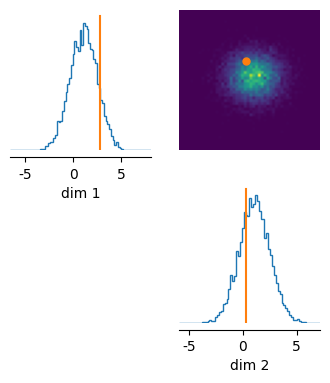

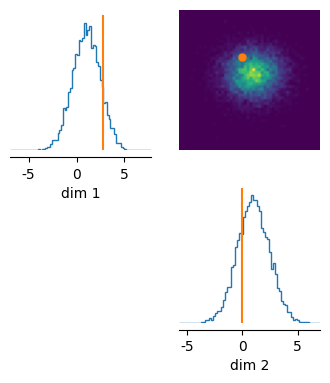

In [7]:
# Prior checks: does observation fall in prior support
plot_checker(x1,x_obs1)
plot_checker(x2,x_obs2)

 Neural network successfully converged after 113 epochs.

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\inference\posteriors\mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


  0%|          | 0/10000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\2D Gaussian Example\sbi-logs\NPE_C\2026-02-04T16_23_04.516139' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(Î¸|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([[2.7484, 0.2764]])


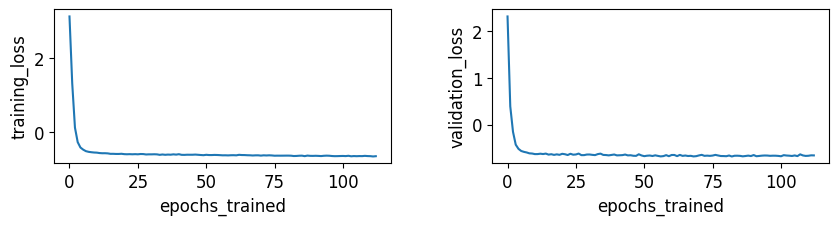

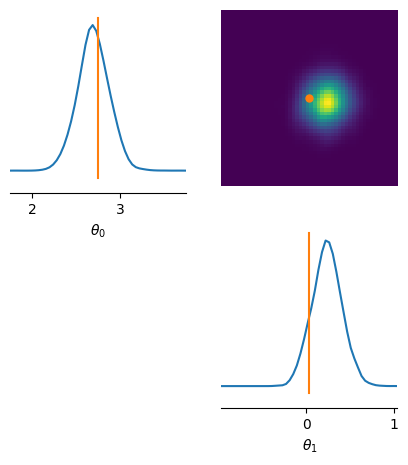

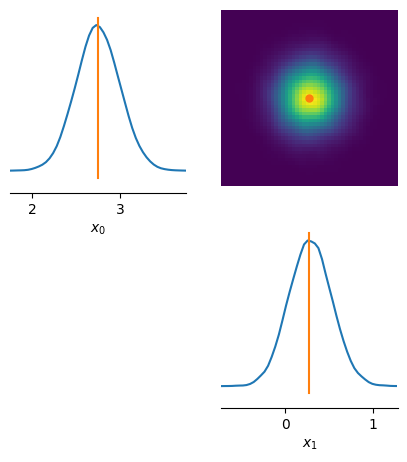

In [10]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(x1,theta,x_obs1, prior, verbose = True, max_epoch=max_epoch, true_val=theta_observed, loc=loc1, scale=scale1)

 Neural network successfully converged after 97 epochs.

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\inference\posteriors\mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


  0%|          | 0/10000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\2D Gaussian Example\sbi-logs\NPE_C\2026-02-04T16_43_05.521555' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(Î¸|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([[ 2.8010, -0.0144]])


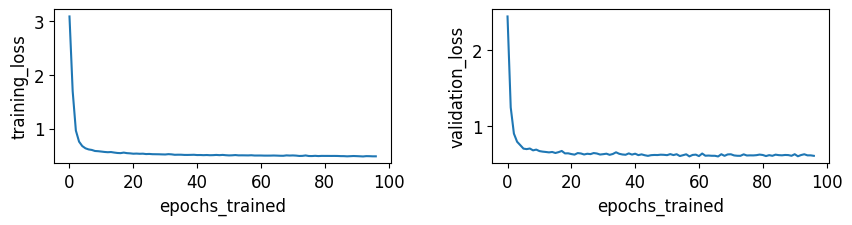

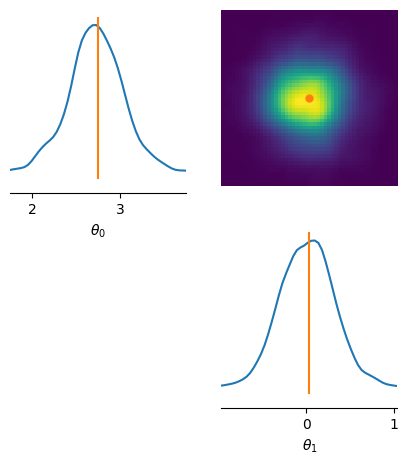

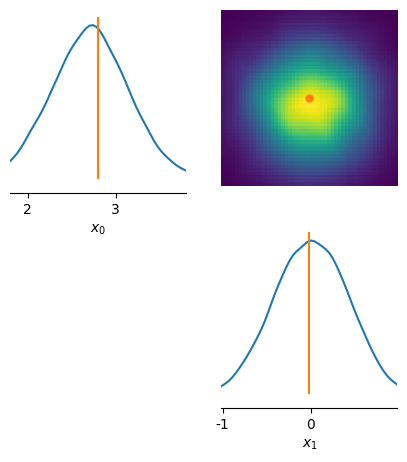

In [11]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(x2,theta,x_obs2, prior, verbose = True, max_epoch=max_epoch, true_val=theta_observed, loc=loc2, scale=scale2)

## POSTERIOR CHECKS/SBC - Needs adapting still

In [ ]:
'''
posterior_samples = posterior1_mcmc.sample((10,), x=x_obs)
posterior_predictives = parallel_simulate(posterior_samples)

posterior_predictive_summary_stats = torch.as_tensor(
    np.asarray([summarize_simulation(sim) for sim in simulation_outputs]),
    dtype=torch.float32
)
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
_ = ax.plot(time_vec, observation[:, 0], c="b")
_ = ax.plot(time_vec, observation[:, 1], c="orange")
for i in range(10):
    _ = ax.plot(time_vec, posterior_predictives[i, :, 0], c="b", alpha=0.2)
    _ = ax.plot(time_vec, posterior_predictives[i, :, 1], c="orange", alpha=0.2)
_ = ax.legend(["Prey", "Predator"])
_ = ax.set_xlabel("Time")
_ = ax.set_ylabel("Population")

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s

prior_samples = prior.sample((num_sbc_samples,))

prior_predictives = parallel_simulate(prior_samples)
prior_predictive_summary_stats = torch.as_tensor(
    np.asarray([summarize_simulation(sim) for sim in prior_predictives]),
    dtype=torch.float32
)

from sbi.diagnostics import run_sbc

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictive_summary_stats,
    posterior,
    reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)

from sbi.analysis.plot import sbc_rank_plot

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    plot_type="cdf",
    num_bins=20,
    figsize=(5, 3),
)


'''

## SAVING RESULTS

In [12]:
results = {
        "samples1": samples1,          # posterior samples (1000, 2)
        "samples2": samples2,          # posterior samples (1000, 2)
        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)
        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)
        "inference1": inference1,      # NPE object
        "inference2": inference2,      # NPE object
        "prior": prior,
        "theta": theta,              # simulated Î¸ used for training (10000, 4)
        "x1": x1,
        "x2": x2,                                   # 
        "x_obs1": x_obs1,              # 
        "x_obs2": x_obs2,
        "loc1": loc1,
        "loc2" : loc2,
        "scale1": scale1, 
        "scale2": scale2,
        "theta_observed": theta_observed                      
    }


fname = f"CALIBRATION TESTER_gaussian_loc1_loc2.pt"
torch.save(results, fname)

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\torch\serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


## KL CALIBRATION CODE

#### Loading Results and Plots to check

In [3]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior",
        "theta",
        "x1", "x2",
        "x_obs1", "x_obs2",
        "loc1","loc2", 
        "scale1","scale2", "theta_observed"
        
    ]

    

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [4]:
fname1 = "CALIBRATION TESTER_gaussian_loc1_loc2.pt"

res = load_results_file(fname1)
# update to include t_span when we retrain models
# update to include true_params if needed but think first
(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior,
 theta,
 x1, x2,
 x_obs1, x_obs2,
 loc1, loc2, scale1, scale2, theta_observed
) = extract_results(res)

C:\Users\vasir\AppData\Local\Temp\ipykernel_30936\3277339583.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


In [5]:
# Define analytical solutions:

def posterior_params(x_obs, loc, scale):
    x_obs = torch.as_tensor(x_obs)
    loc   = torch.as_tensor(loc, dtype=x_obs.dtype, device=x_obs.device)
    s     = torch.as_tensor(scale, dtype=x_obs.dtype, device=x_obs.device)  # variance

    mu_post = (s * torch.ones_like(x_obs) + 2 * (x_obs - loc)) / (s + 2)
    Sigma_post = (2 * s / (s + 2)) * torch.eye(x_obs.numel(), dtype=x_obs.dtype, device=x_obs.device)
    return mu_post, Sigma_post

mu_post1, Sigma_post1 = posterior_params(x_obs1, loc1, scale1)
mu_post2, Sigma_post2 = posterior_params(x_obs2, loc2, scale2)

Text(0.5, 1.05, 'SBI vs analytic marginals, split 2')

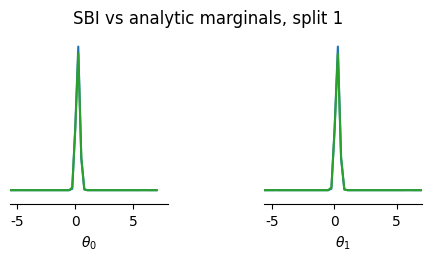

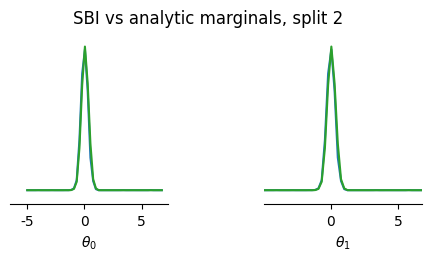

In [7]:
# Plot posteriors vs analytic solutions to check training: 


analytic_samples1 = MultivariateNormal(mu_post1, Sigma_post1, validate_args=False).sample((20_000,)).reshape(-1, 2)
analytic_samples2 = MultivariateNormal(mu_post2, Sigma_post2, validate_args=False).sample((20_000,)).reshape(-1, 2)

fig1, ax1 = marginal_plot(
    samples=[samples1, analytic_samples1],
    diag=["kde", "kde"],
    labels=[r"$\theta_0$", r"$\theta_1$"],
    figsize=(6, 2),
)
fig1.suptitle("SBI vs analytic marginals, split 1", y=1.05)

fig2, ax2 = marginal_plot(
    samples=[samples2, analytic_samples2],
    diag=["kde", "kde"],
    labels=[r"$\theta_0$", r"$\theta_1$"],
    figsize=(6, 2),
)
fig2.suptitle("SBI vs analytic marginals, split 2", y=1.05)



C:\Users\vasir\AppData\Local\Temp\ipykernel_13916\21752523.py:54: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(XX, YY, ZZ, levels=6, colors="black", linewidths=1.0, alpha=0.8, label="Analytic posterior")


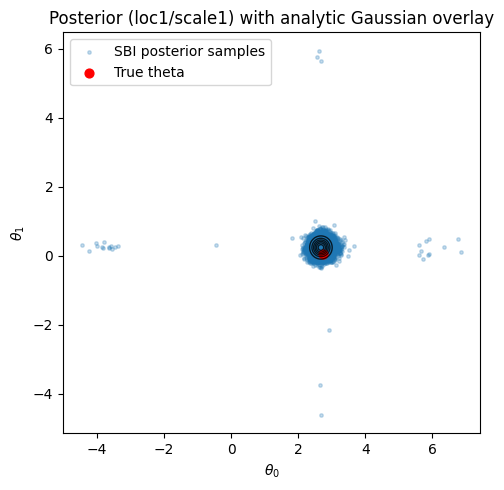

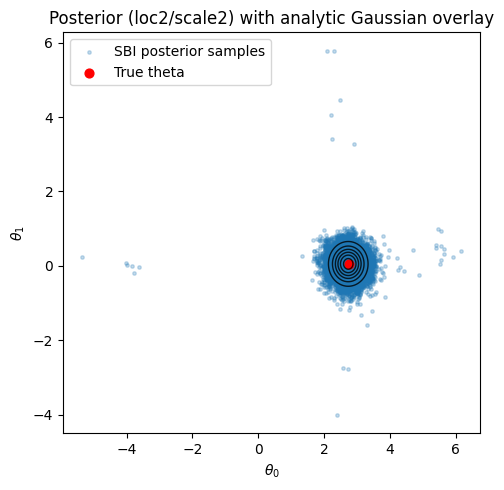

In [ ]:
### Note this cell is gpt generated playing around with codex in vs code


# Overlay analytical Gaussian posterior on top of SBI posterior samples (2D only)
def analytic_posterior_gaussian(
    prior_mean,
    prior_cov,
    x_obs,
    loc,
    scale,
    eps=None,
    likelihood_cov=None,
):
    """
    Closed-form posterior for:
      prior:  theta ~ N(mu0, Sigma0)
      likelihood: x | theta ~ N(theta + loc, Sigma_lik)

    Sigma_lik is built as:
      - isotropic: scale * I
      - with constant off-diagonal correlation: scale * I + eps * (1 - I)
      - or directly supplied as `likelihood_cov` (full covariance matrix)
    """
    mu0 = prior_mean.reshape(-1, 1)
    Sigma0 = prior_cov
    num_dim = Sigma0.shape[-1]

    dtype = Sigma0.dtype
    device = Sigma0.device
    eye = torch.eye(num_dim, dtype=dtype, device=device)

    if likelihood_cov is not None:
        Sigma_lik = torch.as_tensor(likelihood_cov, dtype=dtype, device=device)
        if Sigma_lik.ndim == 0:
            Sigma_lik = Sigma_lik * eye
        elif Sigma_lik.ndim == 1:
            Sigma_lik = torch.diag(Sigma_lik)
    else:
        scale_t = torch.as_tensor(scale, dtype=dtype, device=device)
        if scale_t.ndim == 0:
            Sigma_lik = scale_t * eye
        elif scale_t.ndim == 1:
            Sigma_lik = torch.diag(scale_t)
        else:
            Sigma_lik = scale_t

        if eps is not None:
            eps_t = torch.as_tensor(eps, dtype=dtype, device=device)
            Sigma_lik = Sigma_lik + eps_t * (torch.ones((num_dim, num_dim), dtype=dtype, device=device) - eye)

    loc_t = torch.as_tensor(loc, dtype=dtype, device=device)
    loc_center = loc_t if loc_t.ndim == 0 else loc_t.reshape(-1, 1)

    Sigma0_inv = torch.linalg.inv(Sigma0)
    Sigma_lik_inv = torch.linalg.inv(Sigma_lik)

    x_centered = x_obs.reshape(-1, 1).to(dtype=dtype, device=device) - loc_center
    Sigma_post = torch.linalg.inv(Sigma0_inv + Sigma_lik_inv)
    mu_post = Sigma_post @ (Sigma0_inv @ mu0 + Sigma_lik_inv @ x_centered)
    return mu_post.flatten(), Sigma_post


def plot_posterior_with_gaussian_overlay(
    samples,
    x_obs,
    loc,
    scale,
    prior,
    theta_true,
    title,
    eps=None,
    likelihood_cov=None,
):
    if samples.shape[1] != 2:
        raise ValueError("This overlay plot is only implemented for 2D.")

    prior_mean = prior.loc
    prior_cov = prior.covariance_matrix
    mu_post, Sigma_post = analytic_posterior_gaussian(
        prior_mean,
        prior_cov,
        x_obs,
        loc,
        scale,
        eps=eps,
        likelihood_cov=likelihood_cov,
    )

    # Build grid around posterior mean
    mu_np = mu_post.detach().cpu().numpy()
    Sigma_np = Sigma_post.detach().cpu().numpy()
    stds = np.sqrt(np.diag(Sigma_np))
    grid_min = mu_np - 4 * stds
    grid_max = mu_np + 4 * stds

    gx = np.linspace(grid_min[0], grid_max[0], 200)
    gy = np.linspace(grid_min[1], grid_max[1], 200)
    XX, YY = np.meshgrid(gx, gy)
    grid = np.stack([XX, YY], axis=-1)

    mvn = MultivariateNormal(mu_post, Sigma_post, validate_args=False)
    grid_t = torch.from_numpy(grid).float().reshape(-1, 2)
    ZZ = torch.exp(mvn.log_prob(grid_t)).reshape(200, 200).detach().cpu().numpy()

    samples_np = samples.detach().cpu().numpy()
    theta_true_np = theta_true.detach().cpu().numpy().reshape(-1)

    plt.figure(figsize=(5, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=6, alpha=0.25, label="SBI posterior samples")
    plt.contour(XX, YY, ZZ, levels=6, colors="black", linewidths=1.0, alpha=0.8, label="Analytic posterior")
    plt.scatter(theta_true_np[0], theta_true_np[1], c="red", s=40, label="True theta")
    plt.title(title)
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\theta_1$")
    plt.legend()
    plt.tight_layout()


# Example overlays for the two observation settings
plot_posterior_with_gaussian_overlay(
    samples1, x_obs1, loc1, scale1, prior, theta_observed,
    title="Posterior (loc1/scale1) with analytic Gaussian overlay",
)

plot_posterior_with_gaussian_overlay(
    samples2, x_obs2, loc2, scale2, prior, theta_observed,
    title="Posterior (loc2/scale2) with analytic Gaussian overlay",
    eps=eps if "eps" in globals() else None,
)


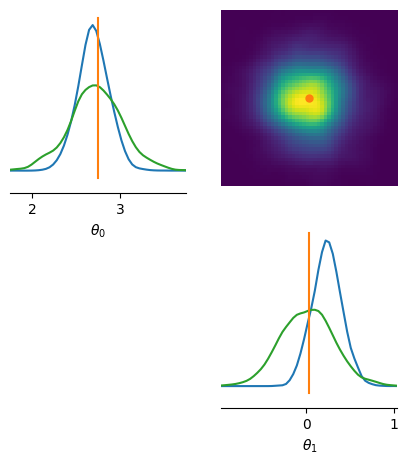

In [8]:
#plot posteriors overlayed

_ = pairplot(
            samples=[samples1, samples2],
            points=theta_observed,
            limits=list(zip(theta_observed.flatten() - 1.0, theta_observed.flatten() + 1.0, strict=False)),
            upper="kde",
            diag="kde",
            figsize=(5, 5),
            labels=[rf"$\theta_{d}$" for d in range(samples1.shape[1])],
            )

#### KL Definitions

In [6]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error

def calibrate_null_dkl(null_posterior, prior, N, n_theta, loc1, scale1, loc2, scale2, dkl_obs):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        
        #print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0)

        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=1, label='Observed D_KL Value')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=1, label='95% Critical Value')
    plt.ylabel("density")
    plt.title("Null calibration of $D_KL$ (data realisations under null)")
    plt.legend()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


0/100
20/100
40/100
60/100
80/100


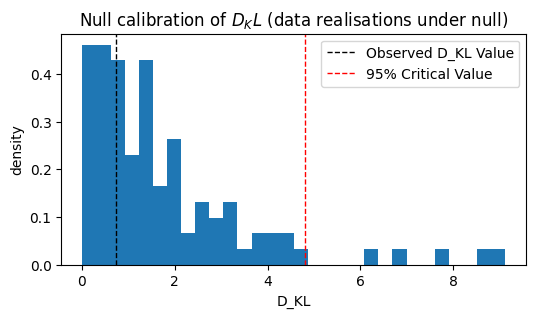

Null 95 percent critical value: 4.8073911905288655
DKL observed: 0.741938054561615


In [7]:

dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior,100,500, loc1, scale1, loc1, scale1, dkl_obs)
print("DKL observed:", dkl_obs)        


In [19]:
def calibrate_null_dkl_neat(null_posterior, prior, N, n_theta, loc1, scale1, loc2, scale2, dkl_obs):
    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 500 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0)

        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) # obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    # ==========================================
    # PLOTTING
    # ==========================================
    # Larger figure size and high DPI for crisp projection
    plt.figure(figsize=(8, 4.5), dpi=150)
    
    # Add a clean grid *behind* the histogram bars
    plt.gca().set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.grid(axis='x', linestyle=':', alpha=0.4)  

    # Original style: solid bars, no gaps
    plt.hist(dkls, bins=30, density=True, color='tab:blue', label='Null Distribution ($H_0$)')
    
    # Vertical lines
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')
    
    # Labels and Titles: Fixed capitalization and added padding so text isn't cramped
    plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
    plt.ylabel("Probability Density", fontsize=14, labelpad=10)
    plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)
    
    # Tick marks: larger fonts
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Upgraded Legend: Solid white background with a crisp border and slight shadow
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    
    # Automatically adjust layout so nothing gets cut off
    plt.tight_layout()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95

0/3000
500/3000
1000/3000
1500/3000
2000/3000
2500/3000


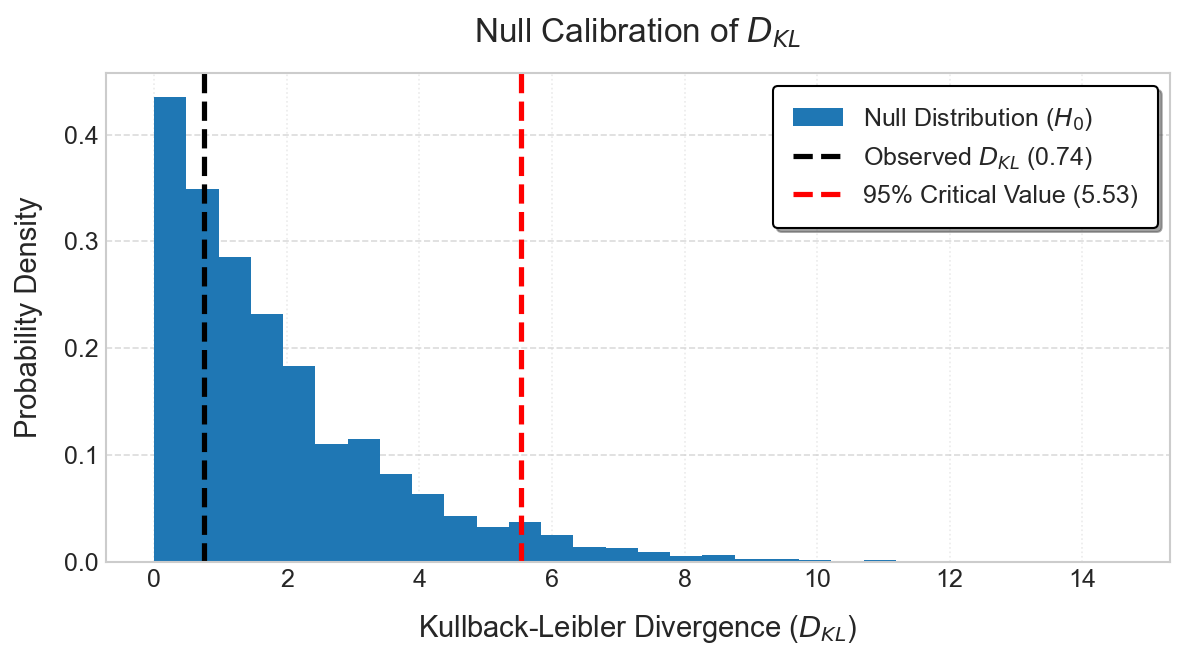

Null 95 percent critical value: 5.528041172027586
DKL observed: 0.741938054561615


In [20]:
dkls_neat, crit_val_95_neat = calibrate_null_dkl_neat(posterior1_direct, prior,3000,500, loc1, scale1, loc1, scale1, dkl_obs)
print("DKL observed:", dkl_obs)        


In [31]:
#loop through N vals to see error as fn of n
N_theta_vals = [100,500,1000,5000,10000]

# empty array to store values
mean_vals=[0]*len(N_theta_vals)
std_dev_vals = [0]*len(N_theta_vals)
error_vals = [0]*len(N_theta_vals)

# generate some random test data, following same process:
def generate_loop_data(prior,loc1, scale1, loc2, scale2):
        theta_i = prior.sample((1,)).squeeze(0)
        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data
        return x1_i, x2_i

x1_loop, x2_loop = generate_loop_data(prior, loc1, scale1, loc1, scale1)

for i in range(len(N_theta_vals)):
        n_theta = N_theta_vals[i]
        mean_vals[i], std_dev_vals[i], error_vals[i] = calc_dkl(posterior1_direct, posterior1_direct, x1_loop, x2_loop, n_theta = n_theta)
        print(i)

0
1
2
3
4


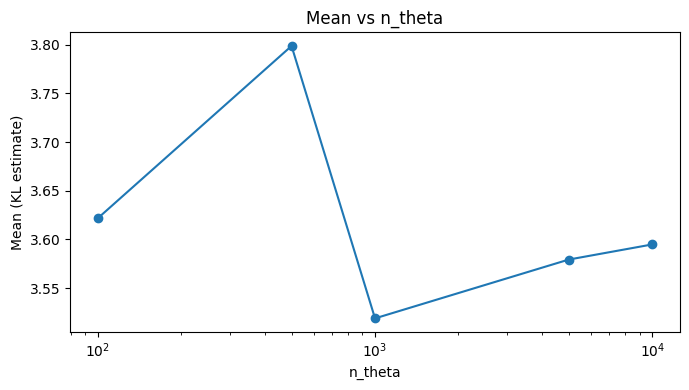

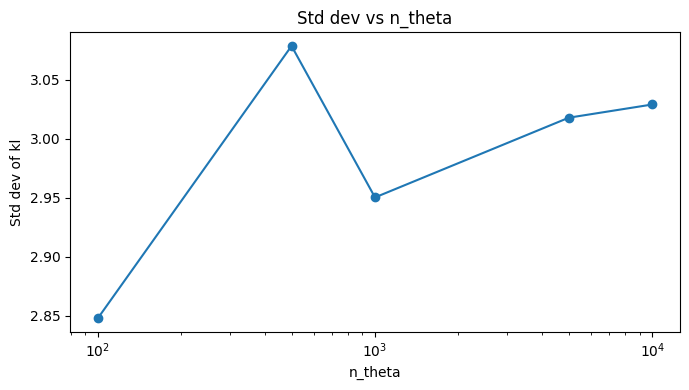

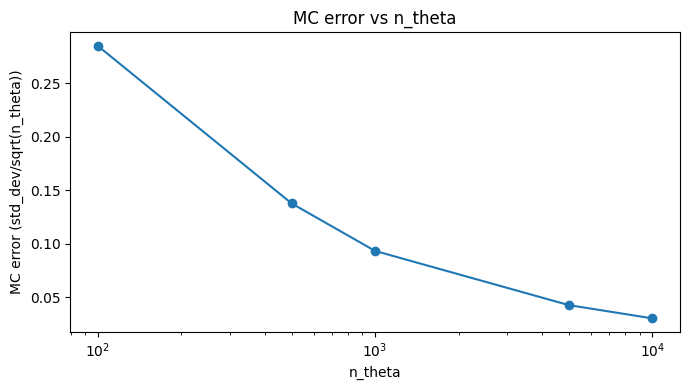

In [32]:

N_theta_vals = np.array(N_theta_vals, dtype=float)
mean_vals = np.array(mean_vals, dtype=float)
std_dev_vals = np.array(std_dev_vals, dtype=float)
error_vals = np.array(error_vals, dtype=float)

# Plot mean
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, mean_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Mean (KL estimate)")
plt.title("Mean vs n_theta")
plt.tight_layout()
plt.show()

# 2) Std dev vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, std_dev_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Std dev of kl")
plt.title("Std dev vs n_theta")
plt.tight_layout()
plt.show()

# 3) Error vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, error_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("MC error (std_dev/sqrt(n_theta))")
plt.title("MC error vs n_theta")
plt.tight_layout()
plt.show()


In [35]:
def calibrate_null_dkl_and_perturbed(null_posterior, prior, N, n_theta, loc1, scale1, loc2, scale2):

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0)
        
        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data
        #### Try more perturbation ideas       
        x1_i_perturbed = simulator(theta_i, loc1+0.1, scale1*1) # shifted mean by 0.1
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    #plot histograms
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Perturbed calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed

0/100
20/100
40/100
60/100
80/100


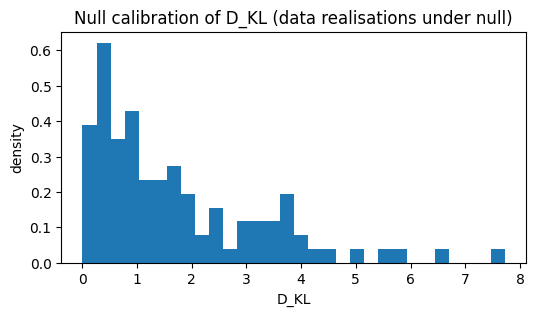

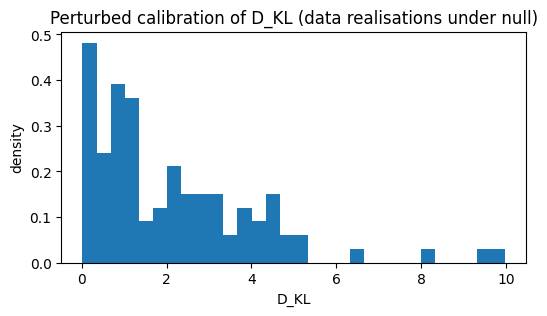

Null 95 percent critical value: 4.594905018806456
Perturbed 95 percent critical value: 5.1327060699462885


In [36]:
dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed = calibrate_null_dkl_and_perturbed(posterior1_direct, prior,100,500, loc1, scale1, loc1, scale1)

In [ ]:
def calc_dkl_count_high_numbers(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2

        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        high_count = sum(x>mean+std_dev for x in z)
        five_count = sum(x>5 for x in z)

        print(f"In {n_theta} samples, {high_count} KL's were more than one std dev above the mean")
        print(f"In {n_theta} samples, {five_count} KL's were more than 5")

        return mean, std_dev, error

In [22]:
from scipy.stats import chi2
def calibrate_null_dkl_and_perturb_mean(null_posterior, prior, N, n_theta, loc1, scale1, loc2, scale2, shift):

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0)
        
        x1_i = simulator(theta_i, loc1, scale1) 
        x2_i = simulator(theta_i, loc2, scale2) #obtaining summary statistics of data
        #### Try more perturbation ideas       
        x1_i_perturbed = simulator(theta_i, loc1+shift, scale1*1) # shifted mean by 0.1
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    # new test stat
    median_perturbed = float(np.median(dkls_perturbed))

    '''
    # analytic Dkl distn
    s = float(scale1) 
    c = 2.0 / (s + 2.0)
    x_max = max(np.max(dkls), 15.0) 
    x_vals = np.linspace(0.01, x_max, 200)
    pdf_theoretical = (1.0 / c) * chi2.pdf(x_vals / c, df=2)
    
    #plot histograms
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True, alpha=0.8, label='NPE Posteriors')
    plt.plot(x_vals, pdf_theoretical, 'r', lw=1, label='Theoretical Scaled $\chi^2_2$')
    plt.legend()
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Perturbed calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)
    '''
    
    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed, median_perturbed

0/1500
100/1500
200/1500
300/1500
400/1500
500/1500
600/1500
700/1500
800/1500
900/1500
1000/1500
1100/1500
1200/1500
1300/1500
1400/1500


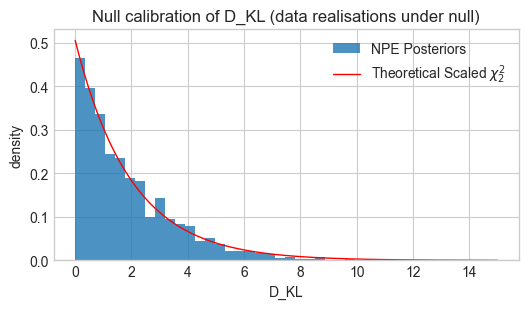

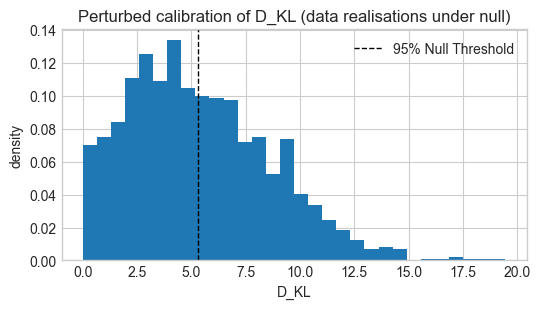

Null 95 percent critical value: 5.298971271514892
Perturbed 95 percent critical value: 11.190064334869383


In [32]:
shifts_to_test = [0.36] # Test shifts from 0 to 0.5
sensitivity_threshold_reached = False

for shift_val in shifts_to_test:
    results = calibrate_null_dkl_and_perturb_mean(posterior1_direct, prior,1500,500, loc1, scale1, loc1, scale1,shift=shift_val)
    null_threshold = results[1]      # crit_val_95
    perturbed_median = results[4]   # median_perturbed
    
    if perturbed_median >= null_threshold:
            print(f">>> 2-Sigma Sensitivity Reached at shift = {shift_val}! <<<")
            sensitivity_threshold_reached = True
            break # We found our sensitivity limit, exit the loop

dkls = results[0]
crit_val_95 = results[1]
dkls_perturbed = results[2]
crit_val_95_perturbed = results[3]
median_perturbed = results[4]

# analytic Dkl distn
s = float(scale1) 
c = 2.0 / (s + 2.0)
x_max = max(np.max(dkls), 15.0) 
x_vals = np.linspace(0.01, x_max, 200)
pdf_theoretical = (1.0 / c) * chi2.pdf(x_vals / c, df=2)

#plot histograms
plt.figure(figsize=(6, 3))
plt.hist(dkls, bins=30, density=True, alpha=0.8, label='NPE Posteriors')
plt.plot(x_vals, pdf_theoretical, 'r', lw=1, label='Theoretical Scaled $\chi^2_2$')
plt.legend()
plt.xlabel("D_KL")
plt.ylabel("density")
plt.title("Null calibration of D_KL (data realisations under null)")
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(dkls_perturbed, bins=30, density=True)
plt.axvline(crit_val_95, color='black', linestyle='dashed', linewidth=1, label='95% Null Threshold')
plt.legend()
plt.xlabel("D_KL")
plt.ylabel("density")
plt.title("Perturbed calibration of D_KL (data realisations under null)")
plt.show()

print("Null 95 percent critical value:", crit_val_95)
print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

In [25]:
median_perturbed = results[4]

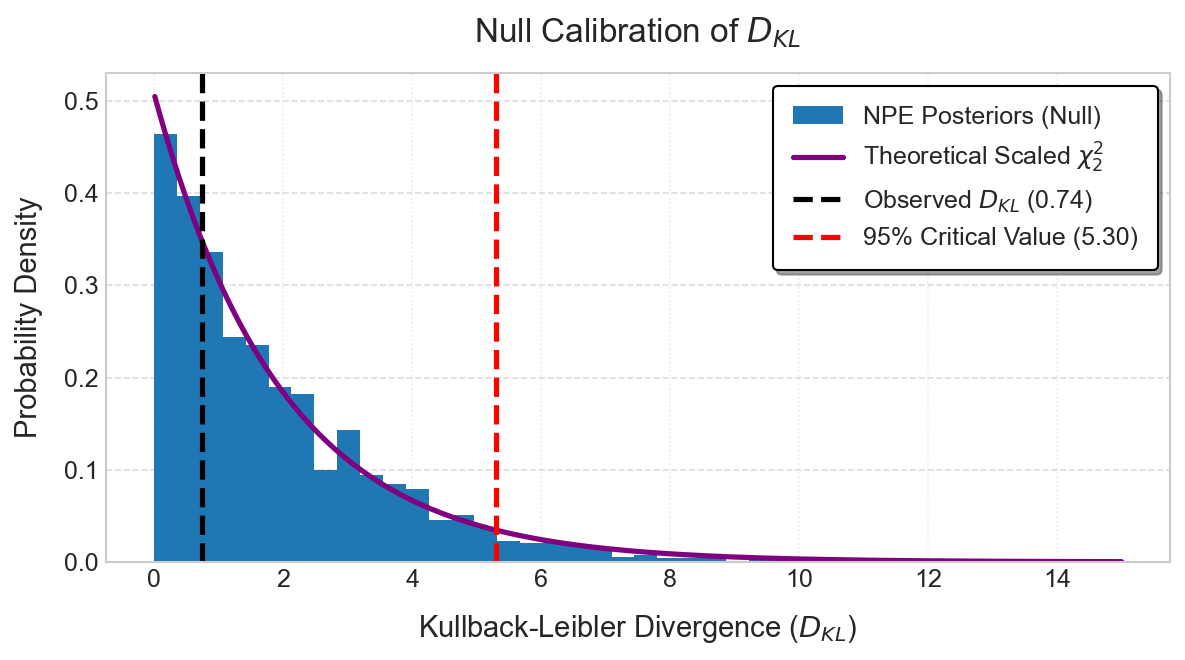

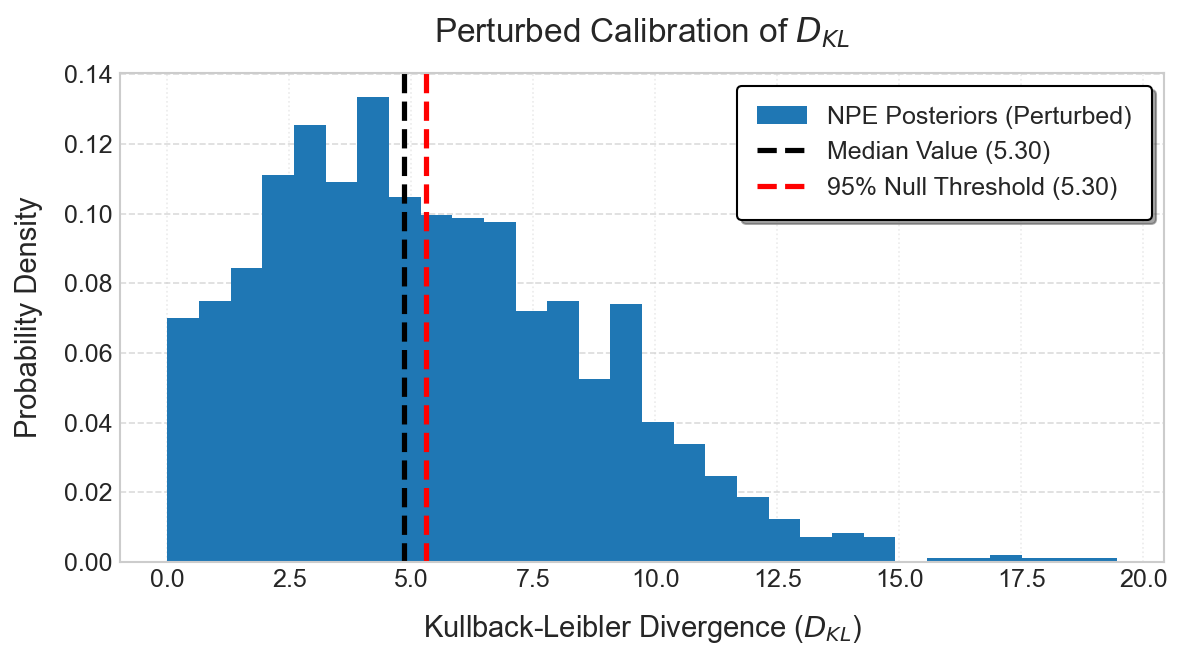

Null 95 percent critical value: 5.30
Perturbed 95 percent critical value: 11.19


In [34]:
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. NULL CALIBRATION GRAPH
# ==========================================
# analytic Dkl distn
s = float(scale1) 
c = 2.0 / (s + 2.0)
x_max = max(np.max(dkls), 15.0) 
x_vals = np.linspace(0.01, x_max, 200)
pdf_theoretical = (1.0 / c) * chi2.pdf(x_vals / c, df=2)

# Plot
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls, bins=30, density=True, color='tab:blue', label='NPE Posteriors (Null)')
# Theoretical line (thicker for the projector)
plt.plot(x_vals, pdf_theoretical, color='purple', linewidth=2.5, label=r'Theoretical Scaled $\chi^2_2$')

plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')



# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()


# ==========================================
# 2. PERTURBED CALIBRATION GRAPH
# ==========================================
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue', label='NPE Posteriors (Perturbed)')

# Vertical threshold line (thicker, with dynamic value injected into legend)
plt.axvline(median_perturbed, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Median Value ({crit_val_95:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
            label=f'95% Null Threshold ({crit_val_95:.2f})')


# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
# Notice I removed "(data realisations under null)" here since this is the perturbed data
plt.title(r"Perturbed Calibration of $D_{KL}$", fontsize=16, pad=15) 

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()

# Print statements formatted to 2 decimal places for neatness
print(f"Null 95 percent critical value: {crit_val_95:.2f}")
print(f"Perturbed 95 percent critical value: {crit_val_95_perturbed:.2f}")